# §4.10 — Attention visualization (Qwen2.5-VL on M8a)

Per-layer / per-head visualization of LM attention weights from the last input token (the query position from which the model generates) to the visual tokens. For each captured layer (5, 15, 20, 25), we reshape the visual-token attention into the 18×18 patch grid and overlay it on the original stimulus image.

**What this is for**: a qualitative complement to the per-layer probe AUC numbers in `notebooks/encoder_saturation_chain.ipynb`. The probes say *what* information is in the encoder; attention maps suggest *where* the LM looks when it commits.

**Capture details**:
- Model: Qwen2.5-VL-7B-Instruct (saturated, project canonical)
- Stim: 20 M8a samples × 3 label roles = 60 inferences (`limit=20` in config)
- Layers: 5 (early), 15 (mid), 20 (late-mid), 25 (late) — 28 layers total
- Heads: 28 per layer
- Visual tokens: 324 (18×18 patch grid)
- Sequence length: 390 tokens (visual span: positions 37–360)
- Saved tensors: `lm_attn_<layer>` shape (28, 390, 390), `visual_token_mask` shape (390,)

Reproducer at the end.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from safetensors.torch import load_file
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

RUN_DIR = sorted(PROJECT_ROOT.glob('outputs/attention_viz_qwen_*'))[-1]
ACT_DIR = RUN_DIR / 'activations'
STIM_DIR = sorted(PROJECT_ROOT.glob('inputs/m8a_qwen_*'))[-1]

preds = pd.read_parquet(RUN_DIR / 'predictions.parquet')
print(f'RUN_DIR  : {RUN_DIR.name}')
print(f'STIM_DIR : {STIM_DIR.name}')
print(f'samples  : {len(preds)} (= {preds["sample_id"].nunique()} stim × {preds["label"].nunique()} labels)')

RUN_DIR  : attention_viz_qwen_20260425-231806_7531ae65
STIM_DIR : m8a_qwen_20260425-091713_8af4836f
samples  : 60 (= 20 stim × 3 labels)


## 1. Load a single capture + inspect shapes

In [2]:
LAYERS = (5, 15, 20, 25)
GRID = 18  # 18×18 patch grid

def load_capture(sample_id: str) -> dict:
    """Load a captured safetensors file by sample_id.

    Returns a dict with:
      - 'attn': {layer -> Tensor(num_heads, q_len, k_len)} as numpy float32
      - 'visual_token_positions': np.ndarray of int positions where input_ids = image token
      - 'visual_token_grid_size': int (18 for our config)
      - 'image': PIL.Image of the stimulus
    """
    d = load_file(str(ACT_DIR / f'{sample_id}.safetensors'))
    mask = d['visual_token_mask'].numpy().astype(bool)
    vis_pos = np.where(mask)[0]
    attn = {li: d[f'lm_attn_{li}'].float().numpy() for li in LAYERS}
    img = Image.open(STIM_DIR / 'images' / f'{sample_id}.png').convert('RGB')
    return {'attn': attn, 'visual_token_positions': vis_pos, 'image': img}

first_id = preds['sample_id'].iloc[0]
cap = load_capture(first_id)
print(f'sample_id: {first_id}')
print(f'visual tokens: {len(cap["visual_token_positions"])}')
print(f'q_len = k_len: {cap["attn"][5].shape[1]}')
print(f'attn shape per layer: {cap["attn"][5].shape}  # (heads, q, k)')

sample_id: circle_line_blank_none_fall_000
visual tokens: 324
q_len = k_len: 390
attn shape per layer: (28, 390, 390)  # (heads, q, k)


## 2. Attention heatmap — last input token → visual grid (per layer, mean over heads)

From the last input token (the position the model is about to generate from), we slice the attention to the 324 visual positions and reshape into an 18×18 grid. Mean over the 28 heads gives a single heatmap per layer.

Layers: 5 (early — generic features), 15 (mid — object semantics), 20 (late-mid), 25 (late — task-conditioning).

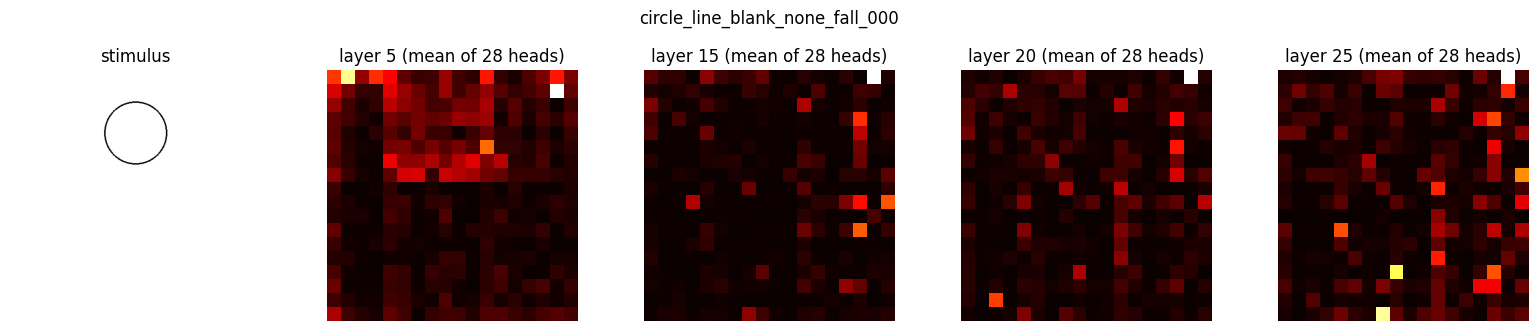

In [3]:
def attn_to_visual_grid(cap: dict, layer: int, query_position: int = -1, head: int | None = None) -> np.ndarray:
    """Slice attention[layer][head, query_position, visual_positions] -> 18×18 grid.

    head=None means average across all heads. query_position=-1 = last input token.
    """
    attn = cap['attn'][layer]                       # (heads, q, k)
    vis = cap['visual_token_positions']             # (324,)
    if head is None:
        a = attn[:, query_position, vis].mean(axis=0)  # (324,)
    else:
        a = attn[head, query_position, vis]            # (324,)
    return a.reshape(GRID, GRID)

def show_attn_grid(cap: dict, *, title: str, layers: tuple = LAYERS) -> None:
    fig, axes = plt.subplots(1, len(layers) + 1, figsize=(3.2 * (len(layers) + 1), 3.2))
    axes[0].imshow(cap['image'])
    axes[0].set_title('stimulus')
    axes[0].axis('off')
    for ax, layer in zip(axes[1:], layers):
        grid = attn_to_visual_grid(cap, layer)
        ax.imshow(grid, cmap='hot', interpolation='nearest')
        ax.set_title(f'layer {layer} (mean of 28 heads)')
        ax.axis('off')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

show_attn_grid(cap, title=f'{first_id}')

## 3. Attention overlay on the original image

Upsample the 18×18 attention grid to the image resolution and alpha-blend with the original. This tells us *where on the image* the LM is looking before generating its response.

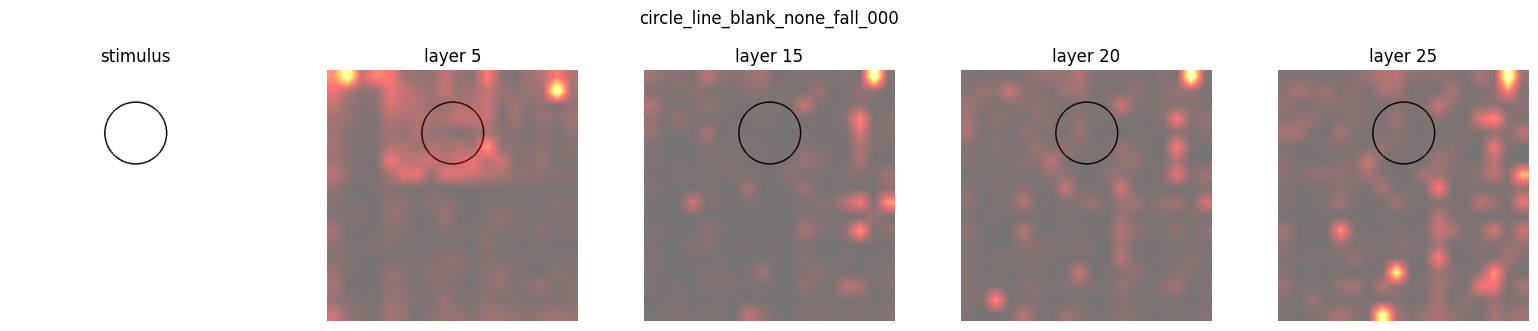

In [4]:
def show_attn_overlay(cap: dict, *, title: str, layers: tuple = LAYERS, alpha: float = 0.55) -> None:
    fig, axes = plt.subplots(1, len(layers) + 1, figsize=(3.2 * (len(layers) + 1), 3.2))
    img = np.asarray(cap['image']).astype(float) / 255
    H, W, _ = img.shape
    axes[0].imshow(img)
    axes[0].set_title('stimulus')
    axes[0].axis('off')
    for ax, layer in zip(axes[1:], layers):
        grid = attn_to_visual_grid(cap, layer)
        # Normalize per-grid (so the overlay shows relative attention within the layer).
        gmin, gmax = float(grid.min()), float(grid.max())
        gnorm = (grid - gmin) / (gmax - gmin + 1e-9)
        big = np.array(Image.fromarray((gnorm * 255).astype(np.uint8)).resize((W, H), Image.BILINEAR)) / 255
        ax.imshow(img)
        ax.imshow(big, cmap='hot', alpha=alpha)
        ax.set_title(f'layer {layer}')
        ax.axis('off')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

show_attn_overlay(cap, title=f'{first_id}')

## 4. Physics-mode vs abstract-mode comparison

Pick a stimulus that elicits a high physics-mode reading and one that does not, and compare attention maps side-by-side. We use the labeled-arm `physical` PMR rating (= 1 if the model committed to physics-mode language) to pick exemplars.

PMR=1 stim count (label=ball): 16 / 20
PMR=0 stim count (label=ball): 4 / 20


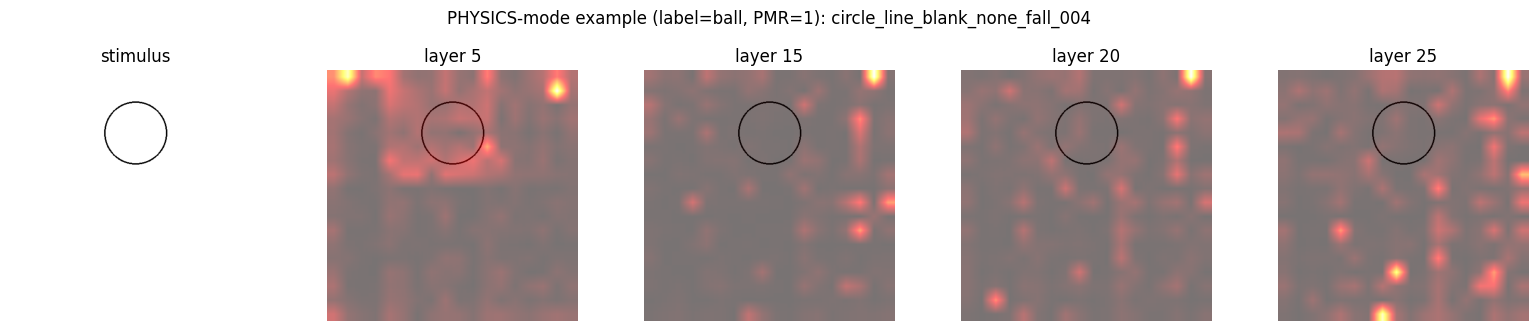

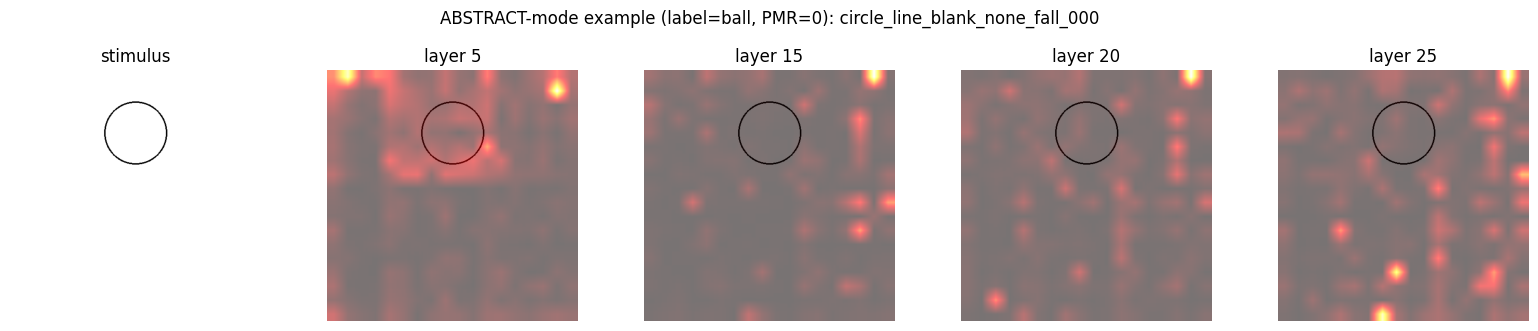

In [5]:
from physical_mode.metrics.pmr import score_rows

scored = score_rows(preds.copy())
scored = scored[scored['label'] == 'ball']  # the project canonical 'physical' label for circle shape

# Find one PMR=1 stim and one PMR=0 stim (if any).
physics_ids = scored.loc[scored['pmr'] == 1, 'sample_id'].tolist()
abstract_ids = scored.loc[scored['pmr'] == 0, 'sample_id'].tolist()

print(f'PMR=1 stim count (label=ball): {len(physics_ids)} / {len(scored)}')
print(f'PMR=0 stim count (label=ball): {len(abstract_ids)} / {len(scored)}')

if physics_ids and abstract_ids:
    show_attn_overlay(load_capture(physics_ids[0]),
                       title=f'PHYSICS-mode example (label=ball, PMR=1): {physics_ids[0]}')
    show_attn_overlay(load_capture(abstract_ids[0]),
                       title=f'ABSTRACT-mode example (label=ball, PMR=0): {abstract_ids[0]}')
elif physics_ids:
    show_attn_overlay(load_capture(physics_ids[0]),
                       title=f'PHYSICS-mode example (label=ball, PMR=1): {physics_ids[0]}')
    print('No PMR=0 sample in the captured subset for label=ball.')

## 5. Per-head fine structure (single layer, all 28 heads)

Layer-mean obscures head specialization. The grid below shows one heatmap per head at a single layer.

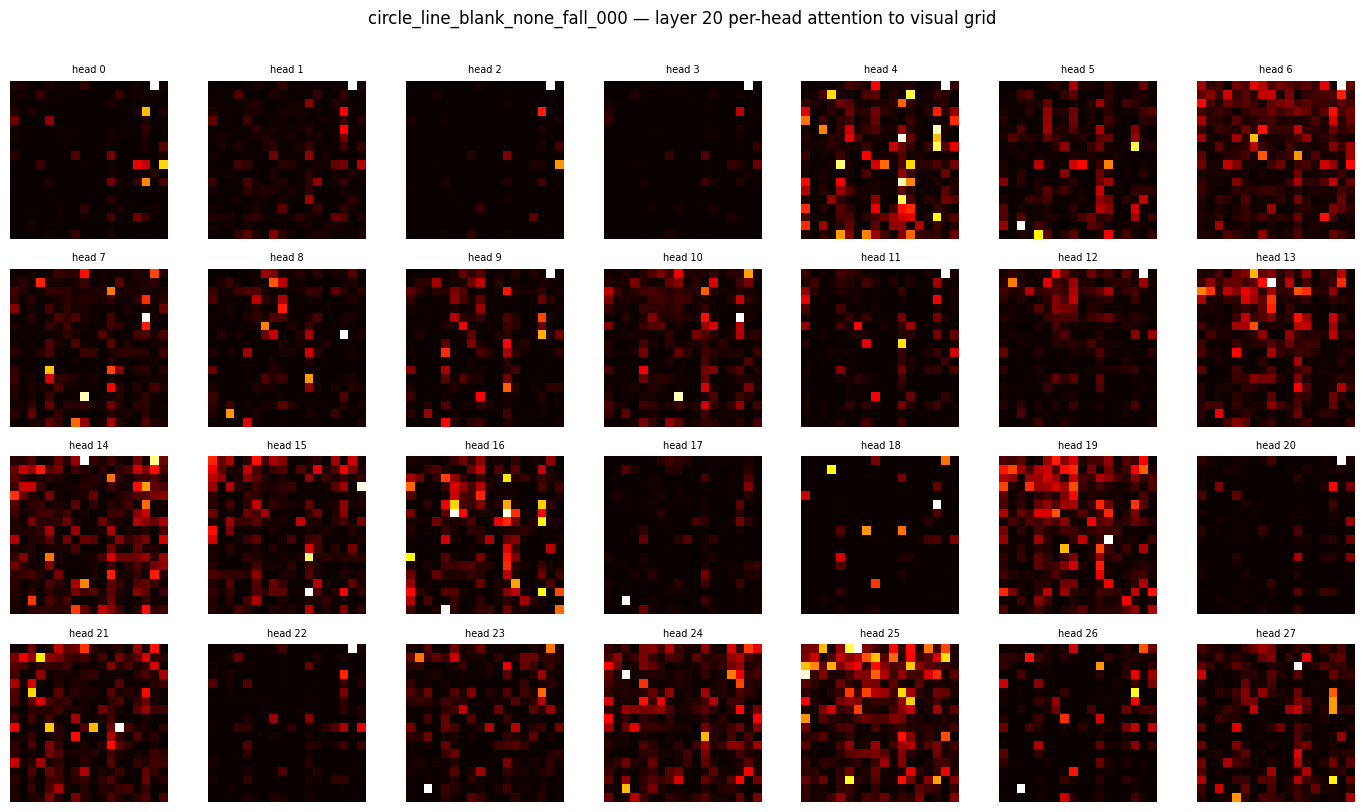

In [6]:
def show_all_heads(cap: dict, layer: int, *, title: str) -> None:
    n_heads = cap['attn'][layer].shape[0]
    n_cols = 7
    n_rows = -(-n_heads // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.0, n_rows * 2.0))
    for h in range(n_heads):
        ax = axes.flat[h]
        grid = attn_to_visual_grid(cap, layer, head=h)
        ax.imshow(grid, cmap='hot', interpolation='nearest')
        ax.set_title(f'head {h}', fontsize=7)
        ax.axis('off')
    for h in range(n_heads, n_rows * n_cols):
        axes.flat[h].axis('off')
    fig.suptitle(f'{title} — layer {layer} per-head attention to visual grid', y=1.01)
    fig.tight_layout()
    plt.show()

show_all_heads(cap, layer=20, title=first_id)

## 6. Aggregate — visual-token attention concentration across the captured subset

For each (sample × label × layer), compute the **entropy** of the attention distribution from the last token to the 324 visual positions. Low entropy = focused attention on a few patches; high entropy = diffuse attention. Plot the per-layer entropy distribution colored by PMR (label=ball arm).

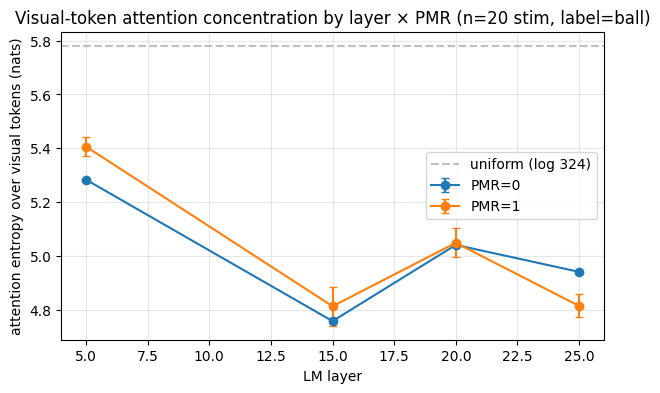

In [7]:
from scipy.stats import entropy

rows = []
for sid in preds.loc[preds['label'] == 'ball', 'sample_id'].unique():
    cap_local = load_capture(sid)
    pmr_row = scored.loc[scored['sample_id'] == sid]
    pmr_val = float(pmr_row['pmr'].iloc[0]) if len(pmr_row) else float('nan')
    for layer in LAYERS:
        a = cap_local['attn'][layer][:, -1, cap_local['visual_token_positions']].mean(axis=0)
        a = a / (a.sum() + 1e-12)
        e = entropy(a + 1e-12)  # nats
        rows.append({'sample_id': sid, 'layer': layer, 'entropy_nats': e, 'pmr': pmr_val})
ent_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
for pmr_val, sub in ent_df.groupby('pmr'):
    by_layer = sub.groupby('layer')['entropy_nats'].agg(['mean', 'std']).reset_index()
    label = f'PMR={pmr_val:.0f}'
    ax.errorbar(by_layer['layer'], by_layer['mean'], yerr=by_layer['std'], marker='o', label=label, capsize=3)
ax.axhline(np.log(324), linestyle='--', color='gray', alpha=0.5, label='uniform (log 324)')
ax.set_xlabel('LM layer')
ax.set_ylabel('attention entropy over visual tokens (nats)')
ax.set_title('Visual-token attention concentration by layer × PMR (n=20 stim, label=ball)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Reproduction

```bash
# 1. Capture (uses M8a Qwen stim, ~30s)
uv run python scripts/02_run_inference.py \
    --config configs/attention_viz_qwen.py \
    --stimulus-dir inputs/m8a_qwen_<ts>

# 2. Run this notebook
uv run jupyter lab notebooks/attention_viz.ipynb
```

Config: `configs/attention_viz_qwen.py` (limit=20, capture_lm_layers=(5, 15, 20, 25), capture_lm_attentions=True, attn_implementation auto-switches to `eager` when capturing).

Required infrastructure change (this round): `src/physical_mode/models/vlm_runner.py` now switches `attn_implementation` to `eager` when `capture_lm_attentions=True`. SDPA does not return attention weights and would silently produce empty `lm_attn_*` tensors.

Outputs:
- `outputs/attention_viz_qwen_<ts>/predictions.{jsonl,parquet,csv}` (60 rows = 20 stim × 3 labels)
- `outputs/attention_viz_qwen_<ts>/activations/<sample_id>.safetensors` (per stim: lm_attn_5/15/20/25, lm_hidden_5/15/20/25, visual_token_mask, input_ids; ~7 MB each)